Shape: (1000, 9)

Columns:
 Index(['Transaction_ID', 'Time', 'Amount', 'Location', 'Transaction_Type',
       'Old_Balance', 'Is_International', 'New_Balance', 'Class'],
      dtype='str')

Info:

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    1000 non-null   int64  
 1   Time              1000 non-null   str    
 2   Amount            1000 non-null   float64
 3   Location          1000 non-null   str    
 4   Transaction_Type  1000 non-null   str    
 5   Old_Balance       1000 non-null   float64
 6   Is_International  1000 non-null   int64  
 7   New_Balance       1000 non-null   float64
 8   Class             1000 non-null   int64  
dtypes: float64(3), int64(3), str(3)
memory usage: 70.4 KB
None

Statistical Summary:

       Transaction_ID        Amount   Old_Balance  Is_International  \
count     1000.000000   1000.00000

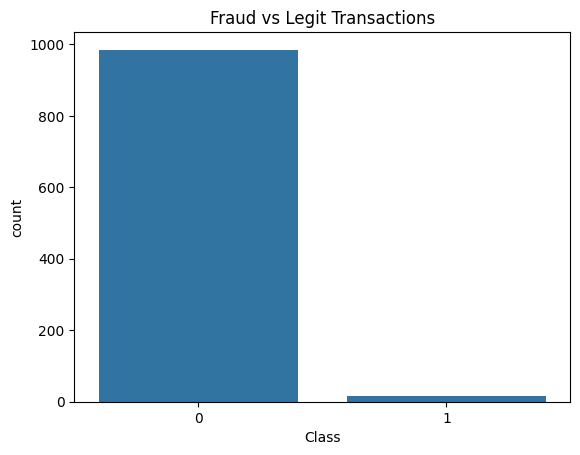

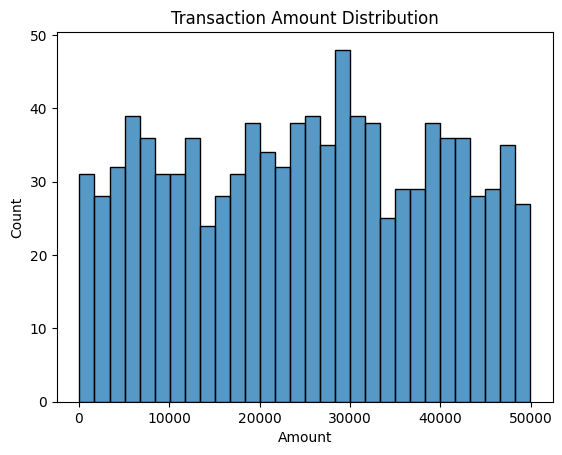

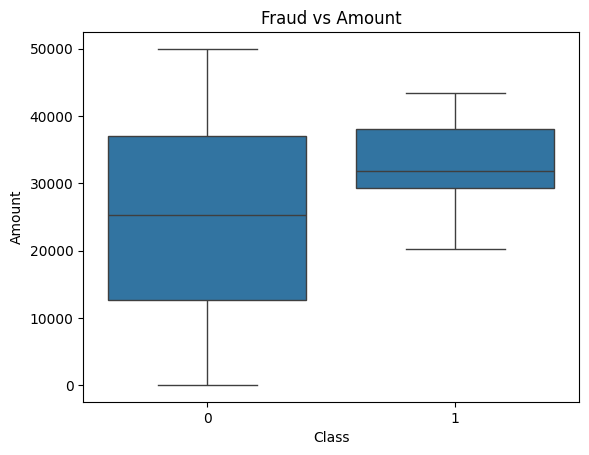

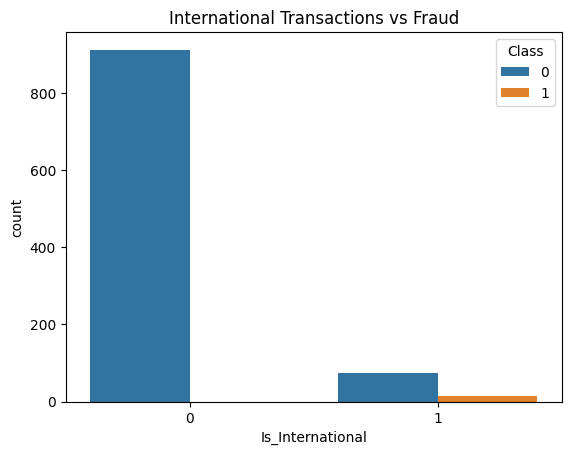

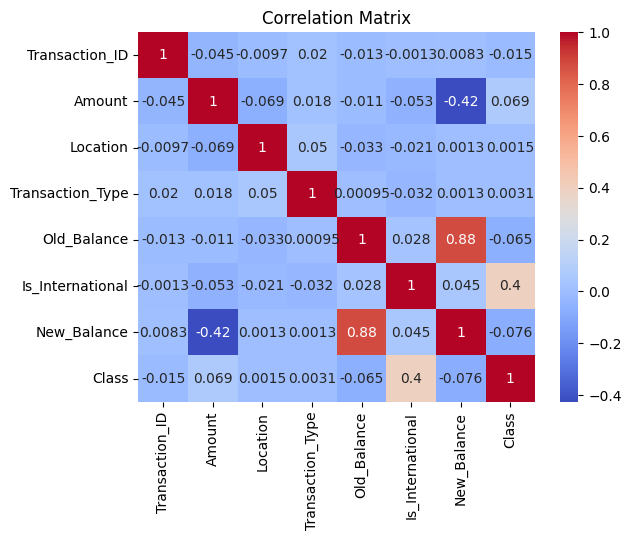

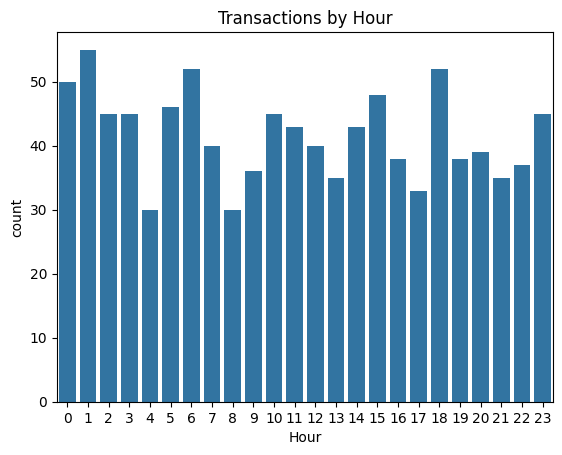

In [3]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD DATASE
df = pd.read_csv("fraud_dataset.csv")

# BASIC INFO
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nInfo:\n")
print(df.info())

# STATISTICAL SUMMARY
print("\nStatistical Summary:\n")
print(df.describe())

# MISSING VALUES
print("\nMissing Values:\n")
print(df.isnull().sum())

# DUPLICATE VALUES
print("\nDuplicate Rows:", df.duplicated().sum())

# ENCODING
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Location'] = le.fit_transform(df['Location'])
df['Transaction_Type'] = le.fit_transform(df['Transaction_Type'])

# TARGET VARIABLE DISTRIBUTION
plt.figure()
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Legit Transactions")
plt.show()

# AMOUNT DISTRIBUTION

plt.figure()
sns.histplot(df['Amount'], bins=30)
plt.title("Transaction Amount Distribution")
plt.show()

# FRAUD VS AMOUNT
plt.figure()
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Fraud vs Amount")
plt.show()

# INTERNATIONAL VS FRAUD
plt.figure()
sns.countplot(x='Is_International', hue='Class', data=df)
plt.title("International Transactions vs Fraud")
plt.show()

# CORRELATION HEATMAP
plt.figure()
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# TIME ANALYSIS
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour

plt.figure()
sns.countplot(x='Hour', data=df)
plt.title("Transactions by Hour")
plt.show()